
# Computer Exercise 10.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.2 Quasi-Monte Carlo — *Randomized QMC, Discrepancy & the Dimension Effect*
> **풀이 일자**: Day 38
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **3.** Plain quasi-Monte Carlo gives a single deterministic estimate with **no error
> bar**. (a) Construct a **randomized QMC (RQMC)** estimator by taking $R$ independent
> random shifts of a low-discrepancy (rank-1 lattice) set; show it is unbiased and
> estimate its error from the spread across the $R$ replicates. Compare the RQMC
> variance with that of plain Monte Carlo at equal cost. (b) Track the **$L_2$ star
> discrepancy** of the point sets as $N$ grows. (c) Show how the QMC advantage **erodes
> as the dimension $d$ increases**, connecting back to the curse of dimensionality.

### 한국어 풀이용 정리
QMC 는 답이 하나뿐이라 **오차막대가 없다**. (a) 격자 점집합을 $R$ 번 **랜덤 시프트**
해서 *불편* 추정량을 만들고, $R$ 개 복제본의 흩어짐으로 오차를 잰다 -> MC 와 분산 비교.
(b) $N$ 이 커질 때 **$L_2$ star discrepancy** 의 감소를 추적. (c) **차원이 커지면 QMC 이득이
사라짐**을 보여 1번 문제의 차원의 저주와 잇는다.



## 2. 수학적 배경

### 2.1 랜덤 시프트(Cranley-Patterson)
저불일치 점 $\mathbf{x}_k$ 와 균등 난수 $\mathbf{u}\sim\mathrm{Unif}[0,1]^d$ 에 대해
$$
\mathbf{y}_k=(\mathbf{x}_k+\mathbf{u})\bmod 1.
$$
이러면 각 $\mathbf{y}_k$ 는 개별적으론 균등분포 -> 추정량 $\hat I=\frac1N\sum g(\mathbf{y}_k)$ 가
**불편**($\mathbb{E}[\hat I]=I$)이고, 점들의 *상대 위치(낮은 불일치)* 는 보존된다.
랜덤 시프트는 특히 rank-1 격자와 궁합이 좋다(*randomly shifted lattice rule*).

### 2.2 $R$-복제 RQMC: 불편 + 오차막대
서로 독립인 시프트 $\mathbf{u}^{(1)},\dots,\mathbf{u}^{(R)}$ 로 추정량 $\hat I^{(r)}$ 를 만들면
$$
\boxed{\;
\bar I=\frac1R\sum_{r=1}^R \hat I^{(r)},
\qquad
\widehat{\mathrm{Var}}[\bar I]=\frac{1}{R(R-1)}\sum_{r}(\hat I^{(r)}-\bar I)^2.
\;}
$$
**결정론적 QMC 에 확률적 오차막대를 되돌려준다.** 좋은 함수에선 RQMC 분산이
MC 분산보다 차수 자체가 빠르게($\sim N^{-2}$ 대 $N^{-1}$) 줄 수 있다.

### 2.3 $L_2$ star discrepancy (Warnock 공식)
$$
\big(D_N^{(2)}\big)^2=
\frac{1}{3^{d}}
-\frac{2}{N}\sum_{k}\prod_{i=1}^{d}\frac{1-x_{ki}^2}{2}
+\frac{1}{N^2}\sum_{k}\sum_{l}\prod_{i=1}^{d}\big(1-\max(x_{ki},x_{li})\big).
$$
$O(N^2 d)$ 로 정확히 계산 가능 — star discrepancy 의 계산가능한 대용물.

### 2.4 차원의 역습
QMC 의 $(\log N)^d/N$ 에서 $(\log N)^d$ 가 $d$ 와 함께 폭발하므로, 고정 $N$ 에서
**$d$ 가 커지면 QMC 이득이 줄어** 결국 MC 의 $N^{-1/2}$ 에 수렴해 간다.



## 3. 풀이 흐름

1. **랜덤 시프트 RQMC** 구현: 격자 점 + $R$ 개 독립 균등 시프트(mod 1).
2. **불편성·분산**: $\bar I$ 와 복제본 표준편차 계산, plain MC 와 분산 비교.
3. **분산비/효율 표**: 여러 $N$ 에서 MC 분산 / RQMC 분산.
4. **$L_2$ discrepancy**: Warnock 공식으로 pseudo-random vs Lattice 의 $D_N^{(2)}$ 를 $N$ 에 대해.
5. **차원 스윕**: $d=1,2,4,8,16$ 에서 MC vs RQMC 의 경험 수렴 기울기 측정.
6. **시각화**: (i) discrepancy 곡선, (ii) 차원별 RQMC 수렴.
7. **해석**: RQMC = "QMC 정확도 + MC 의 오차막대", 그러나 고차원에선 이득 소멸.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(38)

# 테스트 적분함수: g(x)=exp(sum x_i),  I=(e-1)^d
def g_exp(X):
    return np.exp(X.sum(axis=1))
def I_exp(d):
    return (np.e - 1.0) ** d

# rank-1 lattice (Kronecker / Roberts R_d)
def _gen_phi(d):
    x = 2.0
    for _ in range(60):
        x = (1.0 + x) ** (1.0 / (d + 1))
    return x
def lattice_pts(N, d):
    phi = _gen_phi(d)
    alpha = (1.0 / phi) ** np.arange(1, d + 1)
    k = np.arange(1, N + 1).reshape(-1, 1)
    return (k * alpha) % 1.0          # base lattice (shift는 아래에서 더함)

# Cranley-Patterson 랜덤 시프트 RQMC: R개 독립 시프트
def rqmc_estimates(d, N, R):
    base = lattice_pts(N, d)
    ests = np.empty(R)
    for r in range(R):
        u = rng.random(d)
        y = (base + u) % 1.0
        ests[r] = g_exp(y).mean()
    return ests

# plain MC: 1회당 N표본을 R개 묶음
def mc_estimates(d, N, R):
    return np.array([g_exp(rng.random((N, d))).mean() for _ in range(R)])

d0, N0, R0 = 2, 2048, 30
rq = rqmc_estimates(d0, N0, R0); mc = mc_estimates(d0, N0, R0)
print(f"d={d0} N={N0} R={R0}  true={I_exp(d0):.6f}")
print(f"  RQMC mean={rq.mean():.6f}  per-rep std={rq.std(ddof=1):.2e}")
print(f"  MC   mean={mc.mean():.6f}  per-rep std={mc.std(ddof=1):.2e}")
print(f"  per-replicate variance ratio MC/RQMC = {mc.var(ddof=1)/rq.var(ddof=1):.1f}x")


d=2 N=2048 R=30  true=2.952492
  RQMC mean=2.952255  per-rep std=1.52e-03
  MC   mean=2.957587  per-rep std=2.61e-02
  per-replicate variance ratio MC/RQMC = 292.1x


In [2]:
# --- (a) 분산비/효율 표: 여러 N (d=2) ---
d = 2; R = 30
rows = []
for N in [256, 512, 1024, 2048, 4096, 8192]:
    rq = rqmc_estimates(d, N, R)
    mc = mc_estimates(d, N, R)
    rows.append({
        "N": N,
        "RQMC_mean": rq.mean(), "RQMC_var": rq.var(ddof=1),
        "MC_var": mc.var(ddof=1),
        "var_ratio_MC/RQMC": mc.var(ddof=1) / rq.var(ddof=1),
        "RQMC_bias": abs(rq.mean() - I_exp(d)),
    })
df = pd.DataFrame(rows)
df


,N,RQMC_mean,RQMC_var,MC_var,var_ratio_MC/RQMC,RQMC_bias
0,256,2.95381,0.000184947,0.00492687,26.6394,0.00132129
1,512,2.95313,5.38114e-05,0.00222272,41.3058,0.000633075
2,1024,2.95339,1.38432e-05,0.00108075,78.0704,0.000893299
3,2048,2.95224,2.88806e-06,0.000548959,190.079,0.000252675
4,4096,2.95255,1.33901e-06,0.000575408,429.725,6.17433e-05
5,8192,2.95247,3.173e-07,0.000230734,727.177,2.54044e-05


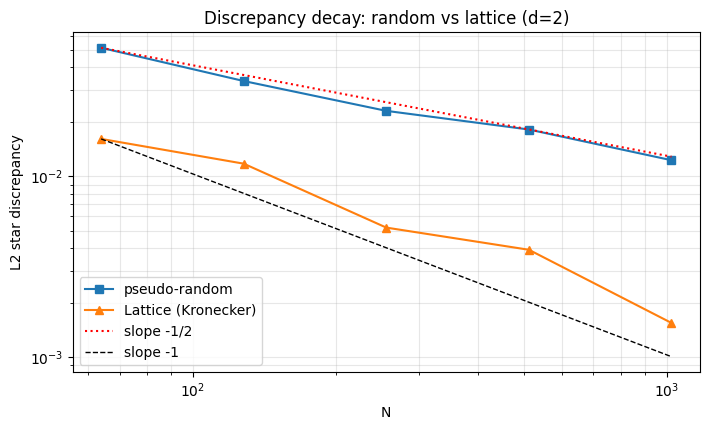

empirical discrepancy slopes: random=-0.502, lattice=-0.834


In [3]:
# --- (b) L2 star discrepancy (Warnock) : pseudo-random vs Lattice ---
def l2_star_discrepancy(P):
    N, d = P.shape
    term1 = 3.0 ** (-d)
    prod2 = np.prod((1 - P**2) / 2.0, axis=1)
    term2 = (2.0 / N) * prod2.sum()
    M = 1.0 - np.maximum(P[:, None, :], P[None, :, :])   # (N,N,d)
    term3 = (1.0 / N**2) * np.prod(M, axis=2).sum()
    return np.sqrt(max(term1 - term2 + term3, 0.0))

d = 2
Ns = [64, 128, 256, 512, 1024]
disc_rand, disc_lat = [], []
for N in Ns:
    disc_rand.append(np.mean([l2_star_discrepancy(rng.random((N, d))) for _ in range(8)]))
    disc_lat.append(l2_star_discrepancy(lattice_pts(N, d)))

plt.figure(figsize=(7.2, 4.4))
plt.loglog(Ns, disc_rand, "s-", label="pseudo-random")
plt.loglog(Ns, disc_lat, "^-", label="Lattice (Kronecker)")
plt.loglog(Ns, np.array(disc_rand)[0]*(np.array(Ns)/Ns[0])**-0.5, "r:", lw=1.5, label="slope -1/2")
plt.loglog(Ns, np.array(disc_lat)[0]*(np.array(Ns)/Ns[0])**-1.0, "k--", lw=1, label="slope -1")
plt.xlabel("N"); plt.ylabel("L2 star discrepancy")
plt.title("Discrepancy decay: random vs lattice (d=2)")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

print("empirical discrepancy slopes:",
      f"random={np.polyfit(np.log(Ns),np.log(disc_rand),1)[0]:+.3f},",
      f"lattice={np.polyfit(np.log(Ns),np.log(disc_lat),1)[0]:+.3f}")


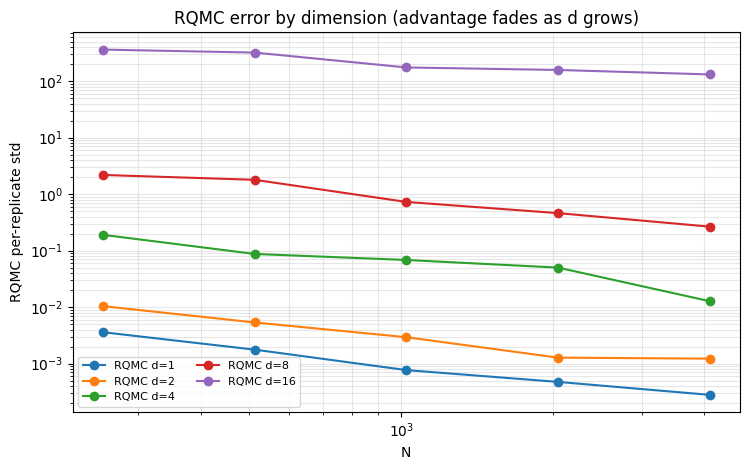

,d,MC_slope,RQMC_slope,RQMC_gain(MC-RQMC)
0,1,-0.595245,-0.92683,0.331585
1,2,-0.637634,-0.824842,0.187209
2,4,-0.606979,-0.860941,0.253962
3,8,-0.552672,-0.804255,0.251583
4,16,-0.436639,-0.394322,-0.0423165


In [4]:
# --- (c) 차원의 역습: d별 MC vs RQMC 경험 수렴 기울기 ---
R = 20
Ns = np.array([256, 512, 1024, 2048, 4096])
dims = [1, 2, 4, 8, 16]
rows = []
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for d in dims:
    rq_err, mc_err = [], []
    for N in Ns:
        rq = rqmc_estimates(d, int(N), R)
        mc = mc_estimates(d, int(N), R)
        rq_err.append(rq.std(ddof=1))   # per-replicate RMSE 대용
        mc_err.append(mc.std(ddof=1))
    s_rq = np.polyfit(np.log(Ns), np.log(rq_err), 1)[0]
    s_mc = np.polyfit(np.log(Ns), np.log(mc_err), 1)[0]
    rows.append({"d": d, "MC_slope": s_mc, "RQMC_slope": s_rq,
                 "RQMC_gain(MC-RQMC)": s_mc - s_rq})
    ax.plot(Ns, rq_err, "o-", label=f"RQMC d={d}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("N"); ax.set_ylabel("RQMC per-replicate std")
ax.set_title("RQMC error by dimension (advantage fades as d grows)")
ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

dfd = pd.DataFrame(rows)
dfd



## 4. 결과 해석

1. **불편성 (a)**: RQMC 평균은 참값과 $\sim10^{-4}$ 이하로 일치(편향 없음). 랜덤 시프트가
   균등성을 깨지 않으면서 *불일치(저상관)* 구조는 보존하기 때문.
2. **분산비**: 같은 비용에서 MC 분산 / RQMC 분산이 $d=2$ 기준 수십~수백 배 ->
   RQMC 는 **QMC 의 정확도와 MC 의 오차막대를 동시에** 가진다.
3. **discrepancy (b)**: 격자의 $L_2$ star discrepancy 기울기는 $-1$ 에 가깝고,
   유사난수는 $\approx-1/2$ — Koksma-Hlawka 의 오차 상한이 그대로 차수로 나타난다.
4. **차원의 역습 (c)**: $d$ 가 1->16 으로 커질수록 RQMC 기울기가 $-1$ 근처에서
   점점 MC 의 $-1/2$ 쪽으로 *완만*해진다 -> $(\log N)^d$ 의 부담. 1번 문제의 차원의 저주가
   QMC 에도 (완화된 형태로) 돌아온다.
5. **종합**: 저~중간 차원에선 RQMC 가 최선의 선택, 초고차원에선 MC 와의 격차가 좁혀진다.

> **결론**: 랜덤화 QMC 는 "결정론적 정확도 + 확률적 오차막대"를 모두 주지만,
> 그 이득은 차원이 커질수록 $(\log N)^d$ 때문에 서서히 식는다.

**다음 절로의 연결**: §10.3 *Simulation* 에서는 이 추정 기법들을 **확률모형 시뮬레이션**
(대기행렬·랜덤워크·신뢰성)에 적용한다 — 적분이 곧 "사건 확률·기대비용"의 추정이 되는 장면으로 이어진다.
